**Explainable AI methods**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


In [4]:
!pip install captum shap lime scikit-image grad-cam --quiet

In [5]:
import numpy as np

In [6]:
from PIL import Image
import requests
from io import BytesIO

# Captum for attributions (Integrated Gradients, Occlusion, GuidedBackprop)

from captum.attr import IntegratedGradients, Occlusion, GuidedBackprop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model = model.eval().to(device)

# Preprocessing tranform for ImageNet models
preprocess = weights.transforms()
imagenet_labels = weights.meta["categories"]

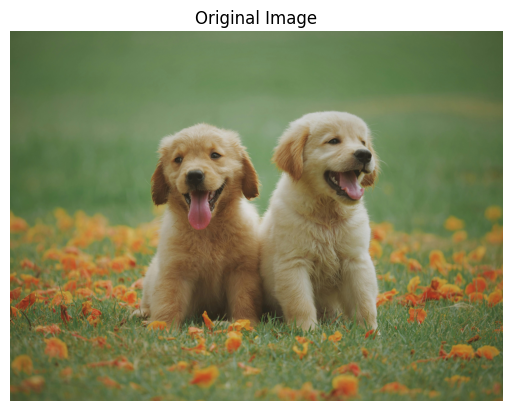

In [8]:
# Example image: a dog (we can take any image that we want)

IMAGE_URL = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
response = requests.get(IMAGE_URL)
img_pil = Image.open(BytesIO(response.content)).convert("RGB")
plt.imshow(img_pil)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [9]:
def prepare_image(img_pil):
    # preprocess returns a tensor [C,H,W], we need [1,C,H,W]
    input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    return input_tensor

def predict(input_tensor):
    with torch.no_grad():
        logits = model(input_tensor)
        probs = logits.softmax(dim=1)
    return probs, logits

input_tensor = prepare_image(img_pil)
probs, logits = predict(input_tensor)
top_prob, top_idx = probs.max(dim=1)
pred_label = imagenet_labels[top_idx.item()]

print(f"Top prediction: {pred_label} (prob={top_prob.item():.3f})")

Top prediction: golden retriever (prob=0.543)


 **1. OCCLUSION** **SENSITIVITY**

We will:
1. Use a pretrained ResNet-50 model.
2. Slide a patch over the input image using Captum’s Occlusion .
3. Visualize the resulting importance heatmap over the original image.

This will give us a first, very intuitive explanation of where the network is “looking”
when it makes its prediction.

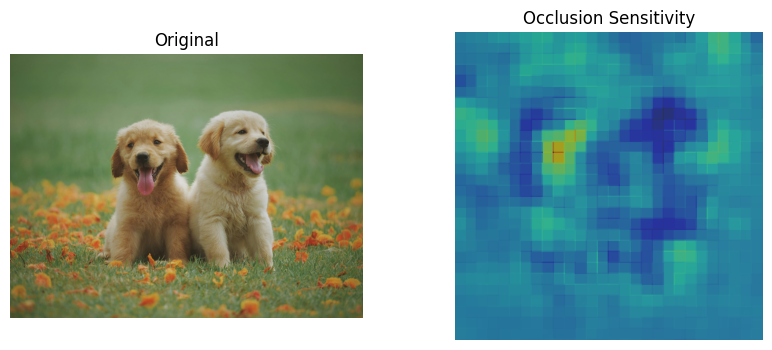

In [10]:
occlusion = Occlusion(model)

# Convert image to tensor with gradient
input_tensor.requires_grad = False

# We’ll focus on the top predicted class
target = top_idx.item()

# Occlusion parameters
# sliding window size: 15x15, stride: 8
attributions_occ = occlusion.attribute(
    input_tensor,
    strides=(1, 8, 8),
    target=target,
    sliding_window_shapes=(1, 15, 15),
    baselines=0
)

# Aggregate over channels (sum)
attr_occ = attributions_occ.squeeze().detach().cpu().numpy()
attr_occ = attr_occ.sum(axis=0)

# Normalize for visualization
attr_occ_norm = (attr_occ - attr_occ.min()) / (attr_occ.max() -
attr_occ.min() + 1e-8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")


plt.subplot(1,2,2)
plt.imshow(img_pil)
plt.imshow(attr_occ_norm, cmap="jet", alpha=0.5)
plt.title("Occlusion Sensitivity")
plt.axis("off")
plt.show()

**2. Integrated Gradients (IG)**

We will:
1. Use a pretrained ResNet-50 classifier.
2. Choose a simple baseline (all-zero image).
3. Use Captum s IntegratedGradients to compute attributions for the predicted
class.
4. Aggregate attributions across channels and overlay them as a heatmap on the
original image.

This will show which pixels contribute most to the model’s prediction, according to
Integrated Gradients.

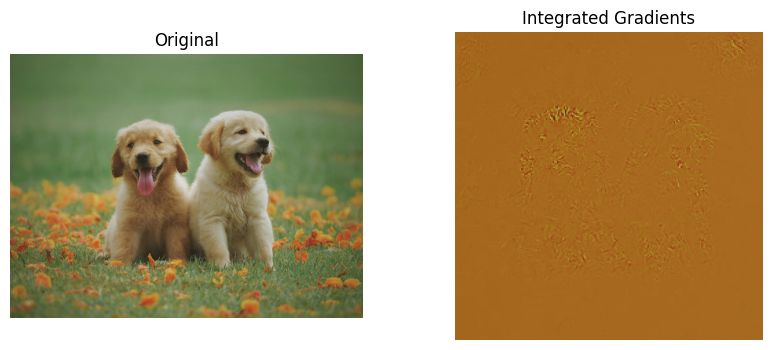

In [11]:
ig = IntegratedGradients(model)

baseline = torch.zeros_like(input_tensor).to(device)

attributions_ig = ig.attribute(
    input_tensor,
    baselines=baseline,
    target=target,
    n_steps=50
)

attr_ig = attributions_ig.squeeze().detach().cpu().numpy()
attr_ig = attr_ig.sum(axis=0)
attr_ig_norm = (attr_ig - attr_ig.min()) / (attr_ig.max() -
attr_ig.min() + 1e-8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_pil)
plt.imshow(attr_ig_norm, cmap="hot", alpha=0.5)
plt.title("Integrated Gradients")
plt.axis("off")
plt.show()

**3. Guided Backpropagation**

We will:
1. Take our pretrained ResNet-50.
2. Use Captum’s GuidedBackprop implementation.
3. Compute guided backprop attributions for the predicted class.
4. Aggregate absolute gradients across channels and visualize them as a grayscale
saliency map.

This will show a fine-grained “edge sketch” of the regions in the image that most
strongly influence the model’s output.

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/guided_backprop_deconvnet.py:66: UserWarning: Setting backward hooks on ReLU activations.The hooks will be removed after the attribution is finished
  warnings.warn(


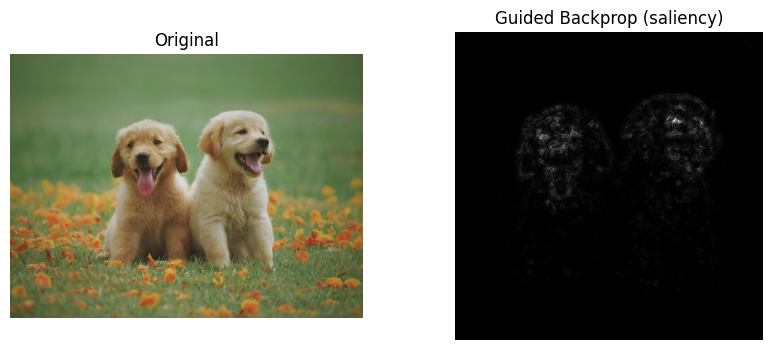

In [12]:
gbp = GuidedBackprop(model)

input_tensor.requires_grad = True

attributions_gbp = gbp.attribute(input_tensor, target=target)
attr_gbp = attributions_gbp.squeeze().detach().cpu().numpy()

# Take absolute values and sum over channels
attr_gbp = np.abs(attr_gbp).sum(axis=0)

attr_gbp_norm = (attr_gbp - attr_gbp.min()) / (attr_gbp.max() -
attr_gbp.min() + 1e-8)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(attr_gbp_norm, cmap="gray")
plt.title("Guided Backprop (saliency)")
plt.axis("off")
plt.show()

**Dependencies for next methods :**

In [1]:
!pip install numpy==2.0 --quiet

We also need to setup and preprocess again as different packages require different Numpy versions.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# LIME for images
from lime import lime_image
from skimage.segmentation import mark_boundaries

# SHAP
import shap

# Grad-CAM family
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Captum for attributions (Integrated Gradients, Occlusion, GuidedBackprop)
from captum.attr import IntegratedGradients, Occlusion, GuidedBackprop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model = model.eval().to(device)

# Preprocessing transform for ImageNet models
preprocess = weights.transforms()
imagenet_labels = weights.meta["categories"]

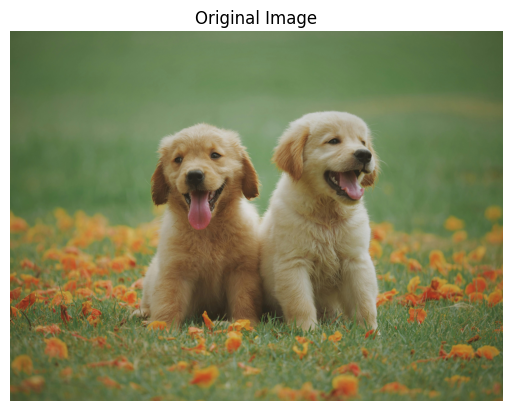

In [4]:
# Example image: a dog (change if you like)
IMAGE_URL = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"

response = requests.get(IMAGE_URL)
img_pil = Image.open(BytesIO(response.content)).convert("RGB")
plt.imshow(img_pil)
plt.axis("off")
plt.title("Original Image")
plt.show()

In [5]:
def prepare_image(img_pil):
    # preprocess returns a tensor [C,H,W], we need [1,C,H,W]
    input_tensor = preprocess(img_pil).unsqueeze(0).to(device)
    return input_tensor

def predict(input_tensor):
    with torch.no_grad():
        logits = model(input_tensor)
        probs = logits.softmax(dim=1)
    return probs, logits

input_tensor = prepare_image(img_pil)
probs, logits = predict(input_tensor)
top_prob, top_idx = probs.max(dim=1)
pred_label = imagenet_labels[top_idx.item()]

print(f"Top prediction: {pred_label} (prob={top_prob.item():.3f})")

Top prediction: golden retriever (prob=0.543)


In [6]:
!pip install shap lime scikit-image grad-cam --quiet

In [7]:
# 1. Prepare input tensor
input_tensor = preprocess(img_pil).unsqueeze(0).to(device) #[1,3,H,W]

# 2. Get prediction
model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    probs = logits.softmax(dim=1)

top_prob, top_idx = probs.max(dim=1)

# 3. Define target class index and label
target = top_idx.item()              # this is what Grad-CAM will explain
pred_label = imagenet_labels[target] # human-readable label

print(f"Top prediction: {pred_label} (class id={target}, prob={top_prob.item():.3f})")

Top prediction: golden retriever (class id=207, prob=0.543)


**3A. Grad-CAM**

We will:
1. Use a pretrained ResNet-50 image classifier.
2. Select the last convolutional block (e.g., 3.model.layer4[-1] ) Use the pytorch-grad-cam library to:
- Compute Grad-CAM
for the predicted class.
- Generate a heatmap.
- Overlay it on the original image as the target layer.

This will show where in the image the model “looks” to justify its current prediction.

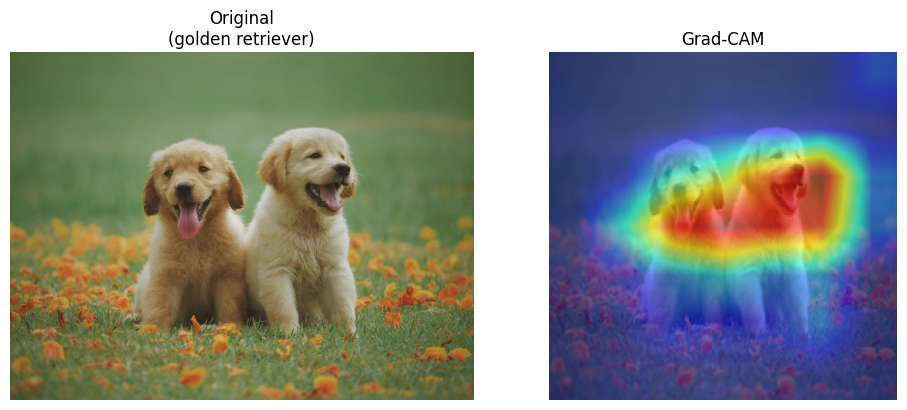

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Make sure model & input are ready
model.eval()
model.to(device)
input_tensor = input_tensor.to(device) # [1,3,H,W]

# 1. Choose target conv layer (last block of ResNet-50)
target_layers = [model.layer4[-1]]

# 2. Create Grad-CAM object
cam = GradCAM(
    model=model,
    target_layers=target_layers
    # use_cuda=(device.type == "cuda") if your version complains, just drop this arg

)

# 3. Target class (top predicted class)
targets = [ClassifierOutputTarget(target)]

# 4. Compute Grad-CAM mask
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]  # [H_cam, W_cam]

# 5. Resize the original image to the same size as the mask
H_cam, W_cam = grayscale_cam.shape
img_resized = img_pil.resize((W_cam, H_cam)) # PIL wants (width,height)
rgb_img = np.array(img_resized).astype(np.float32) / 255.0 #[H_cam, W_cam, 3]

# 6. Overlay heatmap on resized image
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# 7. Plot both original and Grad-CAM visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")
plt.tight_layout()
plt.show()

**3B. Grad CAM++**

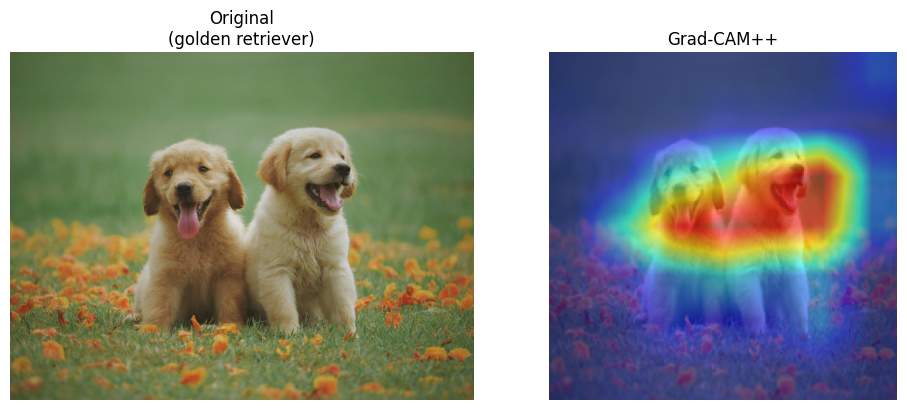

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Make sure model & input are ready
model.eval()
model.to(device)
input_tensor = input_tensor.to(device) # [1,3,H,W]

# 1. Choose target conv layer (last block of ResNet-50) : same as Grad-CAM
target_layers = [model.layer4[-1]]

# 2. Create Grad-CAM++ object
cam_pp = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
    # use_cuda=(device.type == "cuda") if your version complains, just drop this arg
)

# 3. Target class (top predicted class) : same 'target' as before
targets = [ClassifierOutputTarget(target)]

# 4. Compute Grad-CAM++ mask
grayscale_cam_pp = cam_pp(input_tensor=input_tensor, targets=targets)[0] # [H_cam, W_cam]

# 5. Resize the original image to the same size as the mask
H_cam, W_cam = grayscale_cam_pp.shape
img_resized_pp = img_pil.resize((W_cam, H_cam)) # PIL wants (width,height)

rgb_img_pp = np.array(img_resized_pp).astype(np.float32) / 255.0 #[H_cam, W_cam, 3]

# 6. Overlay heatmap on resized image
visualization_pp = show_cam_on_image(rgb_img_pp, grayscale_cam_pp,
use_rgb=True)

# 7. Plot both original and Grad-CAM visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM++")
plt.axis("off")

plt.tight_layout()
plt.show()

**4. LIME**

In [ ]:
# 1. Function that LIME will use to query the model
def batch_predict(images):
    """
    images: list/array of images as float32 in [0,1], shape (H,W,3)
    returns: numpy array of probabilities [N, num_classes]
    """
    model.eval()
    batch_tensors = []

    for img in images:
        # img is HWC, float [0,1] -> uint8 -> PIL
        pil = Image.fromarray((img * 255).astype(np.uint8))
        t = preprocess(pil)             # [3,224,224]
        batch_tensors.append(t)

    batch = torch.stack(batch_tensors).to(device)  # [N,3,224,224]

    with torch.no_grad():
        logits = model(batch)
        probs = logits.softmax(dim=1)

    return probs.cpu().numpy()


# 2. Prepare the original image for LIME (HWC, float in [0,1])
img_lime = np.array(img_pil).astype(np.float32) / 255.0

# 3. Create the LIME image explainer
explainer = lime_image.LimeImageExplainer()

# This step can take a bit of time (num_samples perturbations)
explanation = explainer.explain_instance(
    img_lime,
    batch_predict,
    top_labels=5,
    hide_color=0,
    num_samples=20
)

# 4. Choose which class to explain (use same 'target' as Grad-CAM)
lime_label = target    # or explanation.top_labels[0]

# Get an image & mask of the important superpixels
temp, mask = explanation.get_image_and_mask(
    lime_label,
    positive_only=True,
    num_features=5,   # number of superpixels to highlight
    hide_rest=False
)

# 5. Visualize
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME – important superpixels")
plt.axis("off")

plt.tight_layout()
plt.show()

**5. SHAP**

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as T

model.eval()
model.to(device)
input_tensor = input_tensor.to(device)   # [1,3,H,W]

# 1. Build a small background dataset (random crops of the same image)
background_images = []
bg_transform = T.Compose([
    T.RandomResizedCrop(size=img_pil.size[0], scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(),
])

for _ in range(20):          # 20 background samples is enough for a demo
    bg_pil = bg_transform(img_pil)
    bg_tensor = preprocess(bg_pil)       # [3,224,224]
    background_images.append(bg_tensor)

background = torch.stack(background_images).to(device)  # [20,3,224,224]

# 2. Create DeepExplainer
explainer_shap = shap.DeepExplainer(model, background)

# 3. Compute SHAP values for the current image
#    shap_values is a list of length = num_classes (1000 for ImageNet)
shap_values = explainer_shap.shap_values(input_tensor)

# 4. Take SHAP values for the target class
#    shap_values[target]: [1, 3, H, W]
sv = shap_values[target][0]              # [3,H,W]

# Aggregate over color channels (mean)
sv_agg = sv.mean(axis=0)                 # [H,W]
sv_agg = sv_agg.cpu().numpy()

# Normalize to [-1,1] for visualization
max_abs = np.max(np.abs(sv_agg)) + 1e-8
sv_norm = sv_agg / max_abs               # now in [-1,1]

# 5. Resize original image to same size as SHAP map (should already be 224x224)
H_shap, W_shap = sv_norm.shape
img_resized_shap = img_pil.resize((W_shap, H_shap))
rgb_img_shap = np.array(img_resized_shap).astype(np.float32) / 255.0

# 6. Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_pil)
plt.title(f"Original\n({pred_label})")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sv_norm, cmap="bwr")
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("SHAP (raw map)\nred=positive, blue=negative")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rgb_img_shap)
plt.imshow(sv_norm, cmap="bwr", alpha=0.5)
plt.title("SHAP overlay")
plt.axis("off")

plt.tight_layout()
plt.show()
